# Minimum Model Development

## Set Config

In [1]:
# ライブラリのインポート
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import h2o
from h2o.automl import H2OAutoML
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, confusion_matrix

In [2]:
# フォルダ設定
data_dir = '../data/'
output_dir = '../output/'
result_dir = '../output/results'

# date, version
# dateはデータを出力した日付で、特徴量tableにファイル名に含まれる
# 同じ特徴量tableに対して複数回のモデル構築を行う場合は、versionを変更する
date = '20260202_emergency'
model_type = 'minimum'
within = '72h'
ver_no = 1

# データのファイル名
train_csv_minimum = f'{date}_df_development_{within}_train_sampled_without_lag.csv'
test_csv_minimum = f'{date}_df_development_{within}_test_sampled_without_lag.csv'

In [3]:
# 保存するフォルダやファイル名を指定
roc_figure_name = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_ROC_curve.png'
feature_file_name = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_selected_features.csv'
best_model_folder_name = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_h2omodel_best'
model_path_file_name = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_model_path.txt'
SHAP_figure_file_name = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_SHAP_'

In [4]:
# 使用する特徴量
vars = ['female', 'age', 'gcs_e','gcs_v','gcs_m','rass_score','y']

In [5]:
# H2Oの初期化
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "25.0.2" 2026-01-20 LTS; OpenJDK Runtime Environment Microsoft-13053558 (build 25.0.2+10-LTS); OpenJDK 64-Bit Server VM Microsoft-13053558 (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from /workspaces/research-nms-delirium-2025-4/.venv/lib/python3.12/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpjgrr1tmu
  JVM stdout: /tmp/tmpjgrr1tmu/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpjgrr1tmu/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.5
H2O_cluster_version_age:,"1 year, 5 months and 24 days"
H2O_cluster_name:,H2O_from_python_unknownUser_zl3h0i
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,23.55 Gb
H2O_cluster_total_cores:,28
H2O_cluster_allowed_cores:,28
H2O_cluster_status:,"locked, healthy"


## Model Development

In [6]:
# h2oを使ってモデルを学習させる関数
def get_aml_model(path_train: str, path_test: str, vars: list, random_seed: int) -> None:
    # ファイルの読み込み
    train = h2o.import_file(os.path.join(data_dir, path_train))
    train = train[vars]
    test = h2o.import_file(os.path.join(data_dir, path_test))
    test = test[vars]

    # 特徴量と目的変数の指定
    x = train.columns
    y = 'y'
    x.remove(y)
    train[y] = train[y].asfactor()
    test[y] = test[y].asfactor()
    
    # モデルの学習
    aml = H2OAutoML(max_models=20, seed=random_seed)
    aml.train(x=x, y=y, training_frame=train)

    return aml, train, test

In [7]:
# もし特徴量を保存するフォルダがなければ作成
if not os.path.exists(output_dir + 'features/'):
    os.makedirs(output_dir + 'features/')

# 学習に使用した特徴量を書き出す
with open(output_dir + 'features/' + feature_file_name, "w") as file:
    for feat in vars:
        file.write(feat + "\n")

In [9]:
# モデルを学習させる
aml_delirium_full, train_full, test_full = get_aml_model(train_csv_minimum, test_csv_minimum, vars, 710)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |██████████████████████████
07:21:50.861: DeepLearning_1_AutoML_2_20260223_71730 [DeepLearning def_1] failed: java.lang.AssertionError

███████████████████████████████████████| (done) 100%


In [10]:
# それぞれのモデルの性能を確認
lb_delirium_full = aml_delirium_full.leaderboard
lb_delirium_full.head(rows=lb_delirium_full.nrows)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_BestOfFamily_1_AutoML_2_20260223_71730,0.788177,0.526324,0.674704,0.283203,0.420411,0.176745
StackedEnsemble_AllModels_1_AutoML_2_20260223_71730,0.788089,0.526306,0.674625,0.282999,0.420435,0.176766
DRF_1_AutoML_2_20260223_71730,0.786379,0.530385,0.671778,0.283526,0.421293,0.177488
XGBoost_grid_1_AutoML_2_20260223_71730_model_2,0.783937,0.530084,0.665691,0.286621,0.422452,0.178466
XGBoost_grid_1_AutoML_2_20260223_71730_model_3,0.7806,0.533587,0.658731,0.288953,0.424052,0.17982
XGBoost_grid_1_AutoML_2_20260223_71730_model_1,0.77759,0.536792,0.652562,0.290929,0.42549,0.181041
XGBoost_1_AutoML_2_20260223_71730,0.773365,0.540921,0.64434,0.294321,0.427437,0.182703
XGBoost_grid_1_AutoML_2_20260223_71730_model_4,0.770178,0.543449,0.641405,0.296711,0.428692,0.183777
XGBoost_2_AutoML_2_20260223_71730,0.76885,0.544793,0.63758,0.298291,0.429301,0.1843
XRT_1_AutoML_2_20260223_71730,0.758691,0.55606,0.626639,0.305036,0.434295,0.188612


## Evaluate Best Model Performance
Stacked ensampleではSHAPスコアが出せないため、stacked ensemble以外のモデルを取得する。

In [11]:
# 学習結果を表示というセクションのテーブルから、Stacked Ensemble以外のモデルを選び、model_selectedにそのモデル名を入れる
# Stacked Ensemble以外のもののうち、一番性能が良かったものを選ぶ
lb_df = lb_delirium_full.as_data_frame()
filtered_lb = lb_df[~lb_df['model_id'].str.startswith('StackedEnsemble')]
filtered_lb = filtered_lb[filtered_lb['model_id'].str.startswith('XGBoost')] # XGBoostのみに絞る
model_selected = filtered_lb.iloc[0]['model_id']
model_type = model_selected.split('_')[0]
best_model = h2o.get_model(model_selected)
print(f'Best model: {model_type}')

Best model: XGBoost


/workspaces/research-nms-delirium-2025-4/.venv/lib/python3.12/site-packages/h2o/frame.py:1981: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## AUROC

In [12]:
# 最も性能が良かったモデルのパフォーマンスを取得
perf_full = best_model.model_performance(test_full)

# 最も性能が良かったモデルのAUCを確認
auroc_full = perf_full.auc()
print(f"Test AUROC: {auroc_full}")

Test AUROC: 0.6841066075730157


## Precision & Specificity

In [13]:
# 最も性能が良かったモデルを使って予測を行い、結果を保存
predict = best_model.predict(test_full)
test_full['predict'] = predict['p1']
test_df = test_full.as_data_frame()

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


/workspaces/research-nms-delirium-2025-4/.venv/lib/python3.12/site-packages/h2o/frame.py:1981: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [14]:
# 実際のラベルと予測確率を取得
y_true = test_df['y']
y_prob = test_df['predict']

# Sensitivityを指定したときに、そのsensitivityを実現する閾値を求める関数
def find_threshold_for_sensitivity(y_true, y_prob, sensitivity):
    thresholds = np.arange(0.0, 1.0, 0.00001)
    correct_thresholds = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        if recall_score(y_true, y_pred) >= sensitivity:
            correct_thresholds.append(threshold)
        else:
            break
    if correct_thresholds:
        return np.max(correct_thresholds)
    else:
        return None

# 実現したいsensitivityを指定
desired_sensitivity = 0.8

# 指定したsensitivityを実現する閾値を求める
threshold = find_threshold_for_sensitivity(y_true, y_prob, desired_sensitivity)

# 閾値が見つかった場合、その閾値でのprecisionとspecificityを求める
if threshold is not None:
    print(f'Threshold for sensitivity {desired_sensitivity}: {np.round(threshold, 10)}')
    
    # 閾値を使って予測を行う
    y_pred = (y_prob >= threshold).astype(int)
    
    # 実際のラベルと予測されたラベルを用いてprecisionを求める
    precision = precision_score(y_true, y_pred)
    
    # 実際のラベルと予測されたラベルを用いてconfusion matrixを求める
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # True negative, false positiveの値を元にspecificityを求める
    specificity = tn / (tn + fp)

    print(f'Precision: {precision}')
    print(f'Specificity: {specificity}')
else:
    print(f'No threshold found to achieve sensitivity of {desired_sensitivity}')

Threshold for sensitivity 0.8: 0.21262
Precision: 0.46384691880794277
Specificity: 0.4760494059374902


# ROC Curve

Test AUROC: 0.6840224274152701


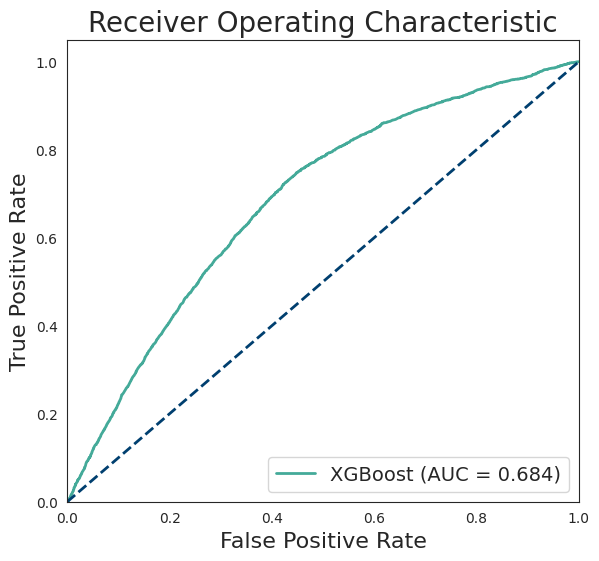

In [15]:
# ROC curveとAUCを求める
fpr1, tpr1, _ = roc_curve(test_df['y'], test_df['predict'])
roc_auc1 = auc(fpr1, tpr1)
print(f'Test AUROC: {roc_auc1}')

# 結果をプロット
plt.figure(figsize=(6.6, 6))
sns.set_style("white")
plt.plot(fpr1, tpr1, color='#44AA99', lw=2, label=f'{model_type} (AUC = {roc_auc1:.3f})')
plt.plot([0, 1], [0, 1], color='#003F6F', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('Receiver Operating Characteristic', fontsize=20)
plt.legend(loc="lower right", fontsize=14)
plt.savefig(os.path.join(output_dir, 'figures/' + roc_figure_name))
plt.show()

### モデルの保存

In [16]:
# 最も性能が良かったモデルを保存し、そのパスをファイルに書き出す
model_path_full = h2o.save_model(model=best_model, path=os.path.join(output_dir, 'results/' + best_model_folder_name), force=True)
# パスが存在しなければ作成する
if not os.path.exists('model_path/'):
    os.makedirs('model_path/')
# パスをファイルに書き出す
with open('model_path/' + model_path_file_name, 'w') as f:
    f.write(model_path_full)

Test AUPRC: 0.5099999904632568


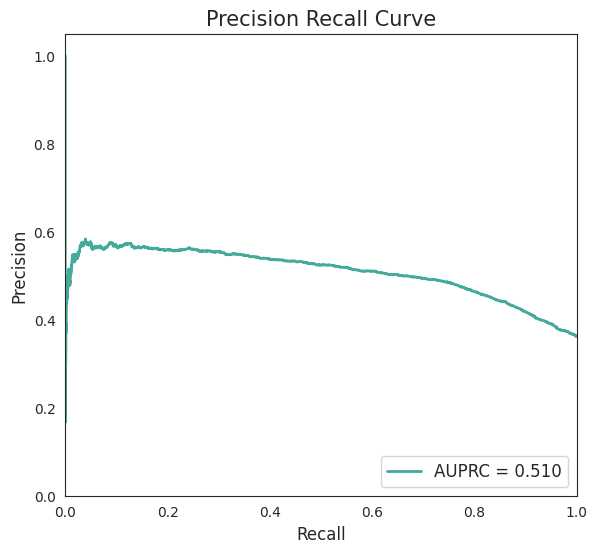

In [17]:
# テストデータに対するAUCPRを計算
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, confusion_matrix

prc_figure_name = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_PRC_curve.png'

precision, recall, thresholds = precision_recall_curve(test_df['y'], test_df['predict'])
aucpr = round(np.float32(auc(recall, precision)), 2)
print(f'Test AUPRC: {aucpr}')

# 結果をプロット
plt.figure(figsize=(6.6, 6))
sns.set_style("white")
plt.plot(recall, precision, color='#44AA99', lw=2, label=f'AUPRC = {aucpr:.3f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision Recall Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.savefig(os.path.join(output_dir, 'figures/' + prc_figure_name))
plt.show()

## SHAPの確認

In [18]:
new_h2o_frame = test_full.drop('y')

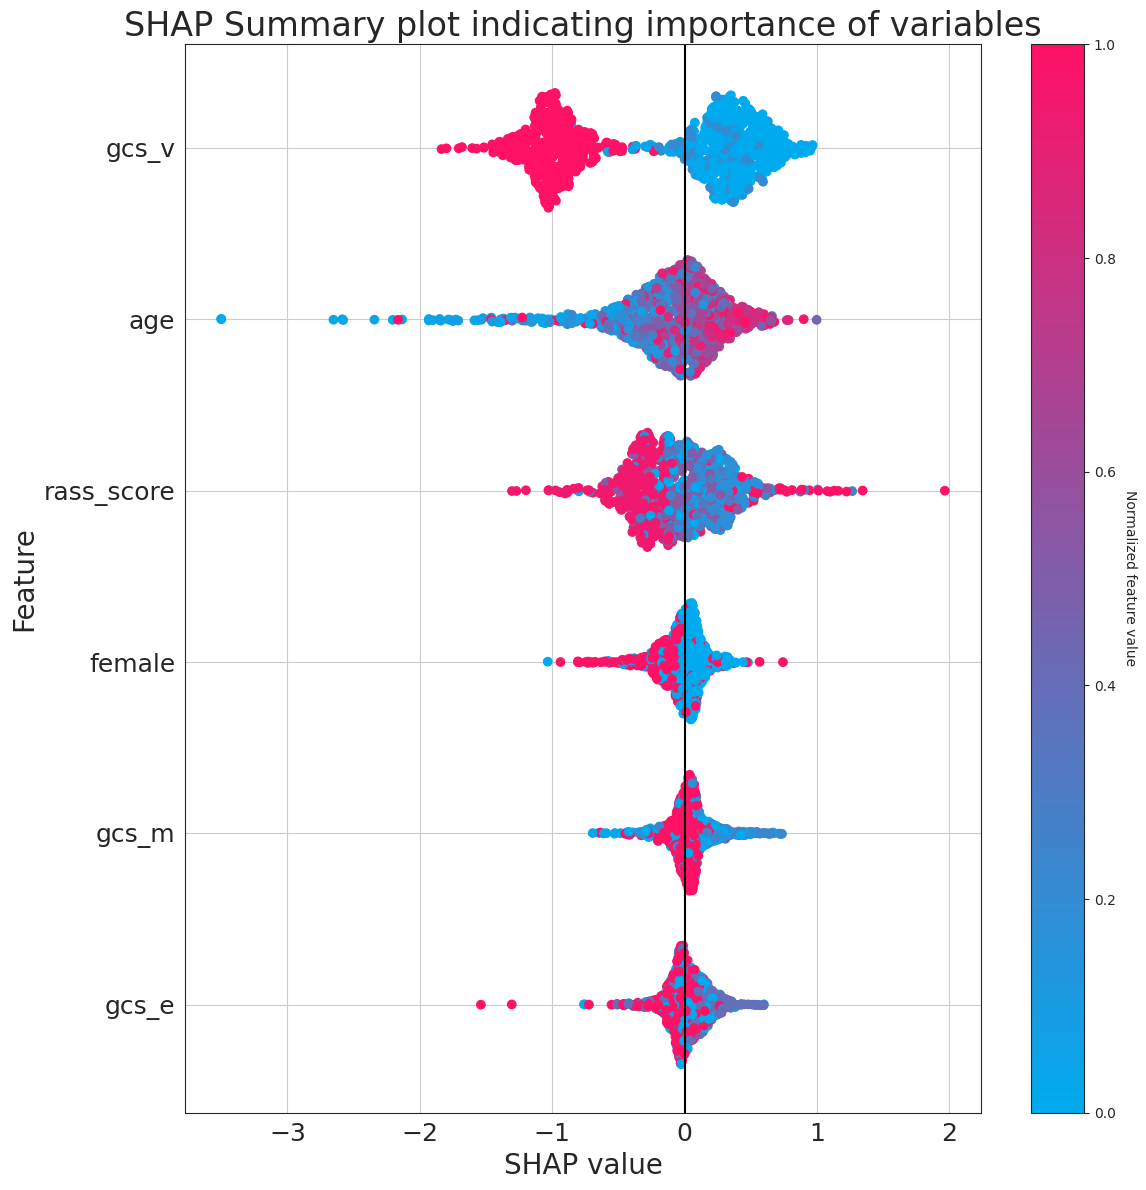

In [19]:
# SHAPのプロットを作成
shap_plot = best_model.shap_summary_plot(new_h2o_frame)

plt.title("SHAP Summary plot indicating importance of variables", fontsize=24)
plt.xlabel(plt.gca().get_xlabel(), fontsize=20)
plt.ylabel(plt.gca().get_ylabel(), fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures/' + SHAP_figure_file_name + model_selected + '.png'))
plt.show()